<a href="https://colab.research.google.com/github/Shamima21/SDtBench-A-Benchmarking-Framework-for-Software-Design-Tools/blob/main/SDtBench_SSME_Score_Calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MSE  = 0.046289
SSIM = 0.586236


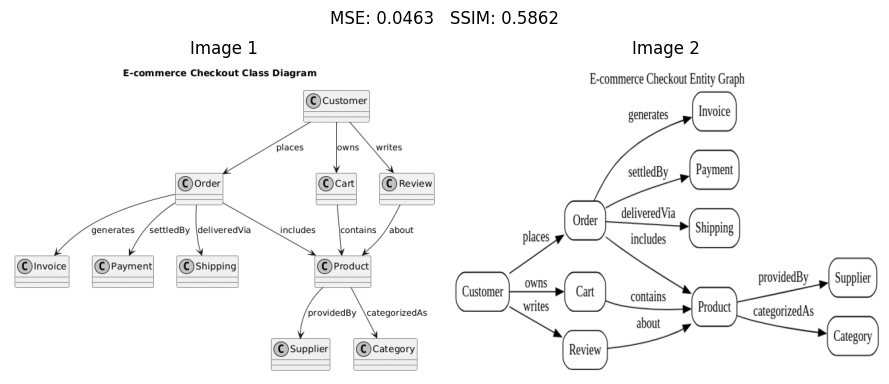

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error

# --- set your image paths here ---
IMG1 = "/content/sample_data/ecommerce.png"     # entity graph
IMG2 = "/content/sample_data/graphviz.png"    # class diagram
# ---------------------------------

def load_gray01(path):
    """Load an image, convert to grayscale, return float array in [0,1]."""
    im = Image.open(path).convert("L")
    arr = np.asarray(im, dtype=np.float32) / 255.0
    return arr

# Load images
im1 = load_gray01(IMG1)
im2 = load_gray01(IMG2)

# If sizes differ, resize second to first (bicubic)
if im2.shape != im1.shape:
    h, w = im1.shape
    im2 = np.asarray(Image.fromarray((im2*255).astype(np.uint8)).resize((w, h), Image.BICUBIC), dtype=np.float32) / 255.0

# Compute metrics (images are in [0,1] → data_range = 1.0)
mse_val  = mean_squared_error(im1, im2)
ssim_val = ssim(im1, im2, data_range=1.0, gaussian_weights=True, sigma=1.5, use_sample_covariance=False)

print(f"MSE  = {mse_val:.6f}")
print(f"SSIM = {ssim_val:.6f}")

# (Optional) visualize
fig, axes = plt.subplots(1, 2, figsize=(9,4), sharex=True, sharey=True)
axes[0].imshow(im1, cmap="gray", vmin=0, vmax=1); axes[0].set_title("Image 1"); axes[0].axis("off")
axes[1].imshow(im2, cmap="gray", vmin=0, vmax=1); axes[1].set_title("Image 2"); axes[1].axis("off")
plt.suptitle(f"MSE: {mse_val:.4f}   SSIM: {ssim_val:.4f}")
plt.tight_layout()
plt.show()
